In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.09456549/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# First look

Enter measurements for species

In [14]:
logN_dict = {
        'HI':'14.4, -0.1, +0.1',
        'HeI':'<12.8',
        'CII':'<13.2',
        'CIII':'14.3, -0.2, +0.2',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.29, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.20, -0.05, +0.05',
        'OVI':'13.8, -0.2, +0.1',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        'AlII':'<11.0',
        'AlIII':'<11.3',
        'SiII':'<12.1',
        'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',
        'FeII':'<11.6'}

Try out a solution

In [15]:
logN_HI_test = 14.4 #14.34
log_hdens_test = -3.5
log_metals_test = 0.3

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

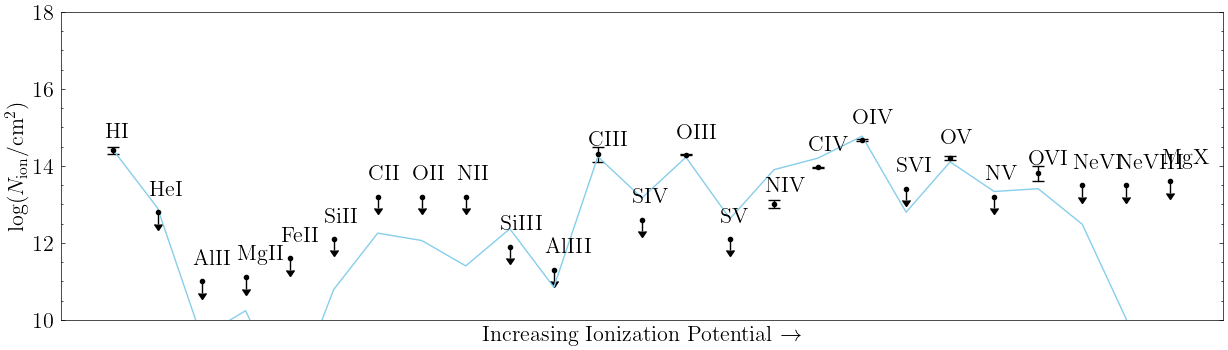

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), np.array(logN_species_test),#+13.2-logN_species_test[7], 
        color='skyblue')

# Single phase solution

In [18]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.29, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.20',
        'OVI':'<13.8',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        'SiII':'<12.1',
        'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',}
        #'FeII':'<11.6'}

Get column density ratios

In [19]:
gen_logN_ratio_str(logN_dict['OVI'], logN_dict['OIV'])

'<-0.87, 0.14'

In [20]:
logN_ratio_dict = {'OII/OIII': '<-1.1, 0.1',
                   'OIV/OIII': '0.38, -0.03, 0.03',
                   'OV/OIV': '<-0.47, -0.1',
                   'OVI/OIV': '<-0.9, 0.1'
                   }

Generate predicted column density ratios

(-2.0, 1.0)

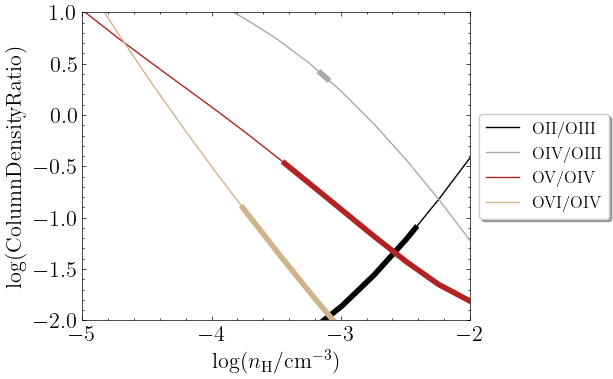

In [21]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -2)
ax.set_ylim(-2, 1)

Fit gas density

In [22]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [23]:
logN_ratio_dict

{'OII/OIII': '<-1.1, 0.1',
 'OIV/OIII': '0.38, -0.03, 0.03',
 'OV/OIV': '<-0.47, -0.1',
 'OVI/OIV': '<-0.9, 0.1'}

In [24]:
pos = np.array(-3.15) + 1e-4 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [25]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [26]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [02:37<00:00,  3.18it/s]


In [27]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_op.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_op.csv')

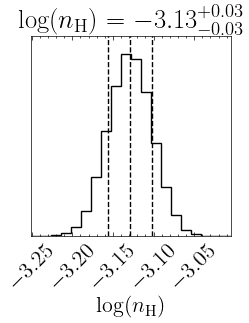

In [28]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [29]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [30]:
logN_offset = 14.29-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate the C/O ratio

In [31]:
logN_CIV_obs = np.random.normal(loc=13.96, scale=0.01, size=len(flat_samples_hdens))

In [32]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [33]:
(np.round(np.median(C_O_dist), 2), 
np.round(np.percentile(C_O_dist, 100*(1-cdf_1sig))-np.median(C_O_dist), 2),
np.round(np.percentile(C_O_dist, 100*cdf_1sig)-np.median(C_O_dist), 2))

(0.09, -0.04, 0.04)

Compute N/O ratio

In [34]:
logN_NIV_obs = np.random.normal(loc=13.0, scale=0.1, size=len(flat_samples_hdens))

In [35]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [36]:
(np.round(np.median(N_O_dist), 2), 
np.round(np.percentile(N_O_dist, 100*(1-cdf_1sig))-np.median(N_O_dist), 2),
np.round(np.percentile(N_O_dist, 100*cdf_1sig)-np.median(N_O_dist), 2))

(-0.8, -0.11, 0.11)

Plot models

In [37]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        'CII':'<13.2',
        'CIII':'14.3, -0.2, +0.2',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.29, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.20, -0.05, +0.05',
        'OVI':'13.8, -0.2, +0.1',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',}
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',
        #'FeII':'<11.6'}

In [38]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

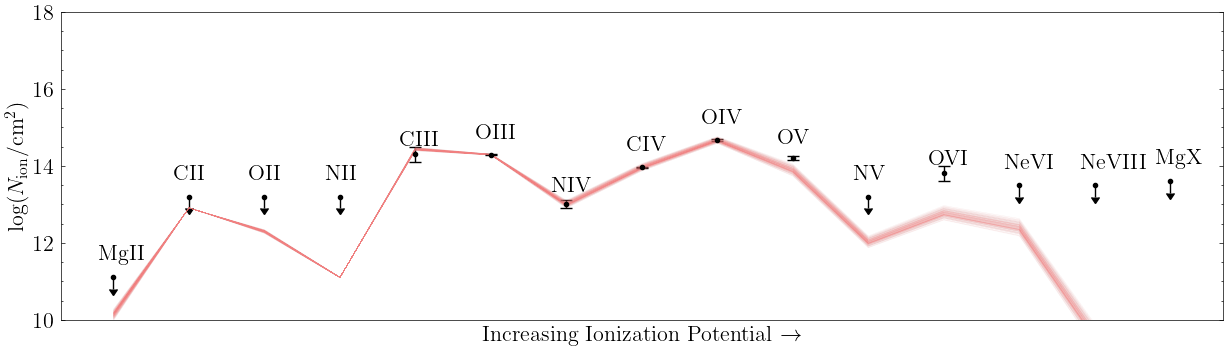

In [39]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'N': np.median(N_O_dist),
                                                                   'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

Get cloud sizes

In [40]:
#l_dist = np.array([get_cloud_size(14.3, log_hdens, species_logN_interp) for log_hdens in flat_samples_hdens['log_hdens']])

In [41]:
#plt.hist(l_dist, bins=45)

In [42]:
get_cloud_size(14.4, -3.13, species_logN_interp)

0.4649714417911553

# Two-phase solution: low density phase

In [43]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [44]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        #'OII':'<13.2',
        'OIII':'<14.29',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.20',
        'OVI':'<13.8',}
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',}
        #'MgII':'<11.1',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',
        #'FeII':'<11.6'}

Get column density ratios

In [45]:
gen_logN_ratio_str(logN_dict['OVI'], logN_dict['OIV'])

'<-0.87, 0.14'

In [46]:
logN_ratio_dict = {#'SIV/OIV' : '<-2.1, 0.1',
                   'OVI/OIV' : '<-0.9, 0.1',
                   'OV/OIV': '<-0.5, 0.1',
                   'OIII/OIV': '<-0.4, 0.1',
                   #'NeVIII/OIV': '<-1.1, 0.2',
                   #'CIII/CIV': '>-0.4, 0.3',
                   #'NV/NIV': '<0.2, 0.2',
                   #'NII/NIV': '<0.2, 0.2'
                  }

(-5.0, 5.0)

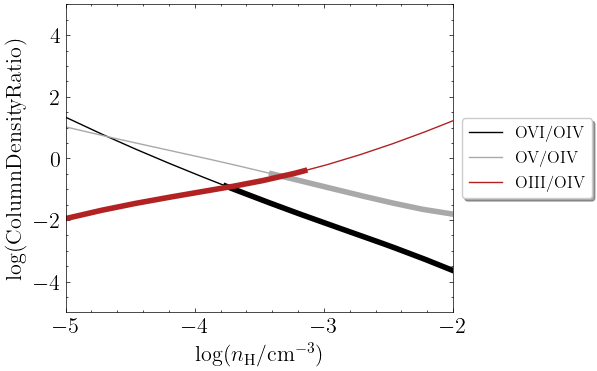

In [47]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -2)
ax.set_ylim(-5, 5)

In [48]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [49]:
pos = np.array(-3.2) + 1e-6 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [50]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [53]:
#sampler.run_mcmc(pos, 500, progress=True);

In [54]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo.csv')

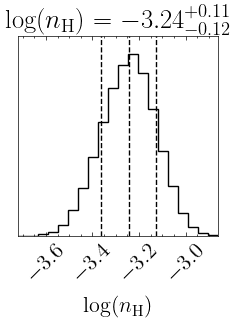

In [55]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [56]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [57]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

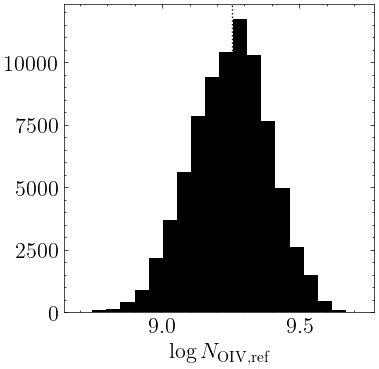

In [58]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

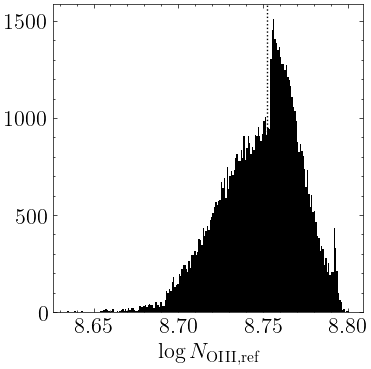

In [59]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

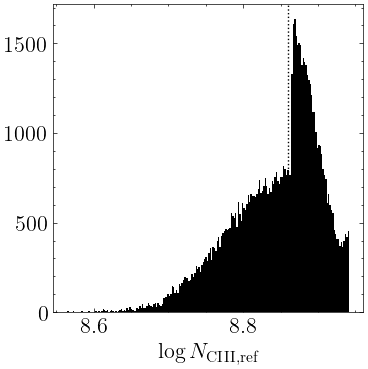

In [60]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [61]:
logN_offset = 14.67-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [62]:
logN_offset

5.414410904833458

Calculate the C/O ratio

In [63]:
logN_CIV_obs = np.random.normal(loc=13.96, scale=0.01, size=len(flat_samples_hdens))

In [64]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [65]:
get_quantiles(C_O_dist)

0.07 -0.14 0.17


Calculate the N/O ratio

In [66]:
logN_NIV_obs = np.random.normal(loc=13.0, scale=0.1, size=len(flat_samples_hdens))

In [67]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [68]:
get_quantiles(N_O_dist)

-0.82 -0.19 0.2


Get yields

In [69]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

14.17 -0.03 0.02


In [70]:
get_quantiles(logN_offset+species_logN_interp['C+2'](grid_points_hdens))

14.27 -0.08 0.04


In [71]:
get_quantiles(logN_offset+species_logN_interp['S+3'](grid_points_hdens))

13.07 -0.15 0.11


Plot models

In [76]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        #'OII':'<13.2',
        'OIII':'14.29, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.20, -0.05, +0.05',
        'OVI':'13.8, -0.2, +0.1',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        #'MgII':'<11.1',
        'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',}
        #'FeII':'<11.6'}

In [77]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

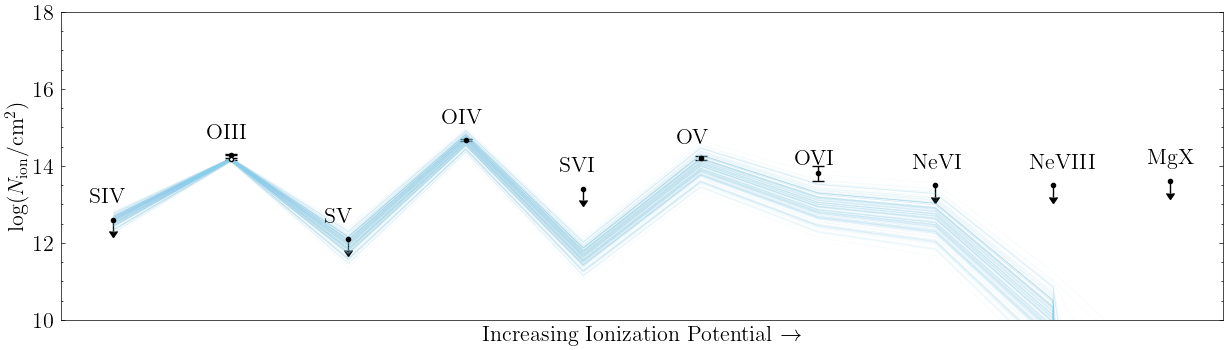

In [79]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=1, y=14.17, yerr=0.03, color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist), 
                                         'N':np.median(N_O_dist),
                                         'S': -0.5})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [80]:
logN_OIII_tot = np.random.normal(loc=14.29, scale=0.02, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=14.17, scale=0.03, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_20841/3957099971.py:3: RuntimeWarning: invalid value encountered in log10
  logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)


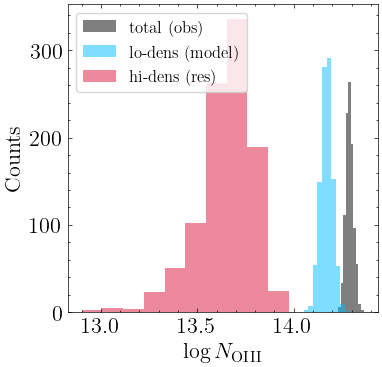

In [81]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [82]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [83]:
get_quantiles(logN_OIII_hi_dens_clean)

13.67 -0.15 0.11


# Two-phase solution: high density phase

In [84]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'13.7, -0.2, +0.1',
        'OIV':'<14.67',
        #'OV':'14.20, -0.05, +0.05',
        #'OVI':'13.8, -0.2, +0.1',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',}
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',}
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',
        #'FeII':'<11.6'}

In [88]:
gen_logN_ratio_str(logN_dict['OII'], logN_dict['OIII'])

'<-0.50, 0.17'

In [89]:
logN_ratio_dict = {
                   'OII/OIII': '<-0.5, 0.2',
                   'MgII/OIII': '<-2.6, 0.2',
                   'OIV/OIII': '<1.0, 0.2',
                  }

(-5.0, 5.0)

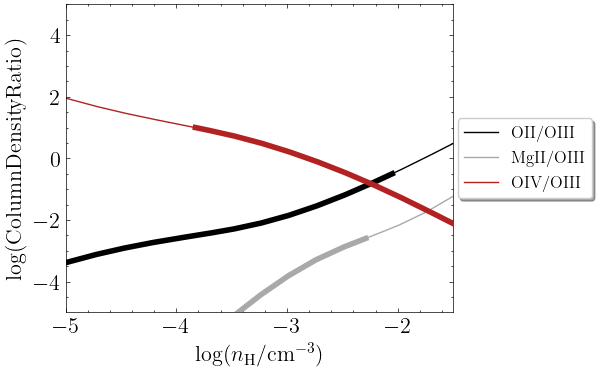

In [90]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [91]:
pos = np.array(-2.8) + 1e-6 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [92]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [93]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [01:58<00:00,  4.23it/s]


In [94]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi.csv')

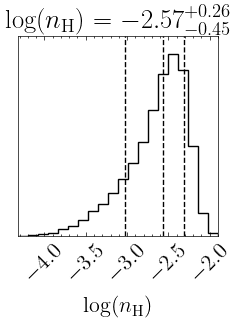

In [95]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [96]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [97]:
logN_offset = 13.7-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [98]:
logN_offset

5.229813107532788

Plot models

In [99]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'13.7, -0.2, +0.1',
        'OIV':'<14.67',
        #'OV':'14.20, -0.05, +0.05',
        #'OVI':'13.8, -0.2, +0.1',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',}
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',}
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',
        #'FeII':'<11.6'}

In [100]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

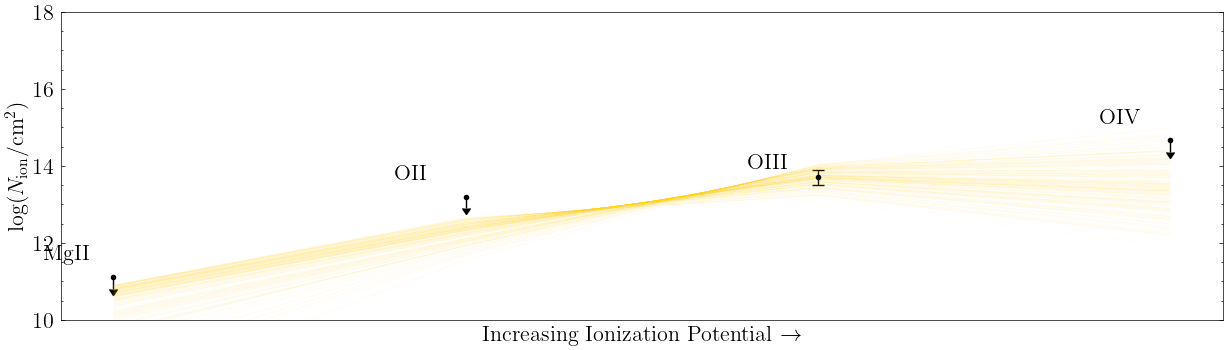

In [102]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [103]:
get_cloud_size(14.3, -2.6, species_logN_interp)

0.02642582341235285

# Two-phase solution: simultaneous

In [104]:
def lambda_log_prior_two_phase(params):
    
    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, logN_HI_p2, log_hdens_p2, log_metals_p2 = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, logN_HI_p2, log_hdens_p2, log_metals_p2])
    
    return log_prior_two_phase(params_full, species_logN_interp)

In [105]:
def lambda_log_likelihood_two_phase(params, logN_dict, species_logN_interp):

    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, logN_HI_p2, log_hdens_p2, log_metals_p2 = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, logN_HI_p2, log_hdens_p2, log_metals_p2])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood_two_phase(params_full, logN_dict, species_logN_interp)    

In [106]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior_two_phase(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood_two_phase(params, logN_dict, species_logN_interp)

Fit things

In [107]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.29, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.20, -0.05, +0.05',
        'OVI':'13.8, -0.2, +0.1',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',}
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',
        #'FeII':'<11.6'}

In [108]:
logN_HI_test = 14.3
log_hdens_test_p1 = -2.5
log_metals_test_p1 = 0.6

logN_HI_test_p2 = 13.4
log_hdens_test_p2 = -3.9
log_metals_test_p2 = 0.7

In [109]:
logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_test, log_hdens_test_p1, log_metals_test_p1, species_logN_interp))
logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_test_p2, log_hdens_test_p2, log_metals_test_p2, species_logN_interp))
logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

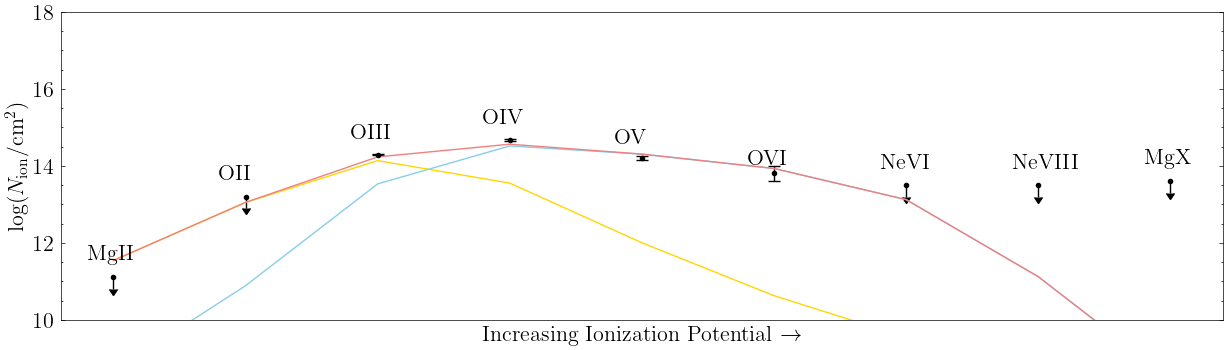

In [110]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='gold')
ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='skyblue')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral')

In [111]:
pos = np.array([log_hdens_test_p1, log_metals_test_p2, 
                logN_HI_test_p2, log_hdens_test_p2, log_metals_test_p2]) + 1e-4 * np.random.randn(200, 5)
nwalkers, ndim = pos.shape

In [112]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [113]:
#species_logN_interp['S+5']([16.67, 0.1, -0.6]), species_logN_interp['S+5']([14.9, -2.7, -1.0]), species_logN_interp['S+5']([14.9, -3.7, -1.0])

In [114]:
sampler.run_mcmc(pos, 500, progress=True);

  7%|██▊                                       | 33/500 [00:27<06:21,  1.22it/s]/Users/thepoetoftwilight/Documents/CUBS/Code/cloudy_fitting/cloudy_fit_lib.py:1015: RuntimeWarning: divide by zero encountered in log
  ll += np.log(integrate.simpson(x=y_range, y=np.exp(-.5*(y_range-y_bar)**2/sig_y**2)))
100%|█████████████████████████████████████████| 500/500 [05:47<00:00,  1.44it/s]


In [115]:
flat_samples_two_phase = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens_p1', 'log_metals_p1', 
                                         'logN_HI_p2', 'log_hdens_p2', 'log_metals_p2'])
flat_samples_two_phase.to_csv(savedir+'two_phase.csv', index=False)

#flat_samples_two_phase = pd.read_csv(savedir+'two_phase.csv')

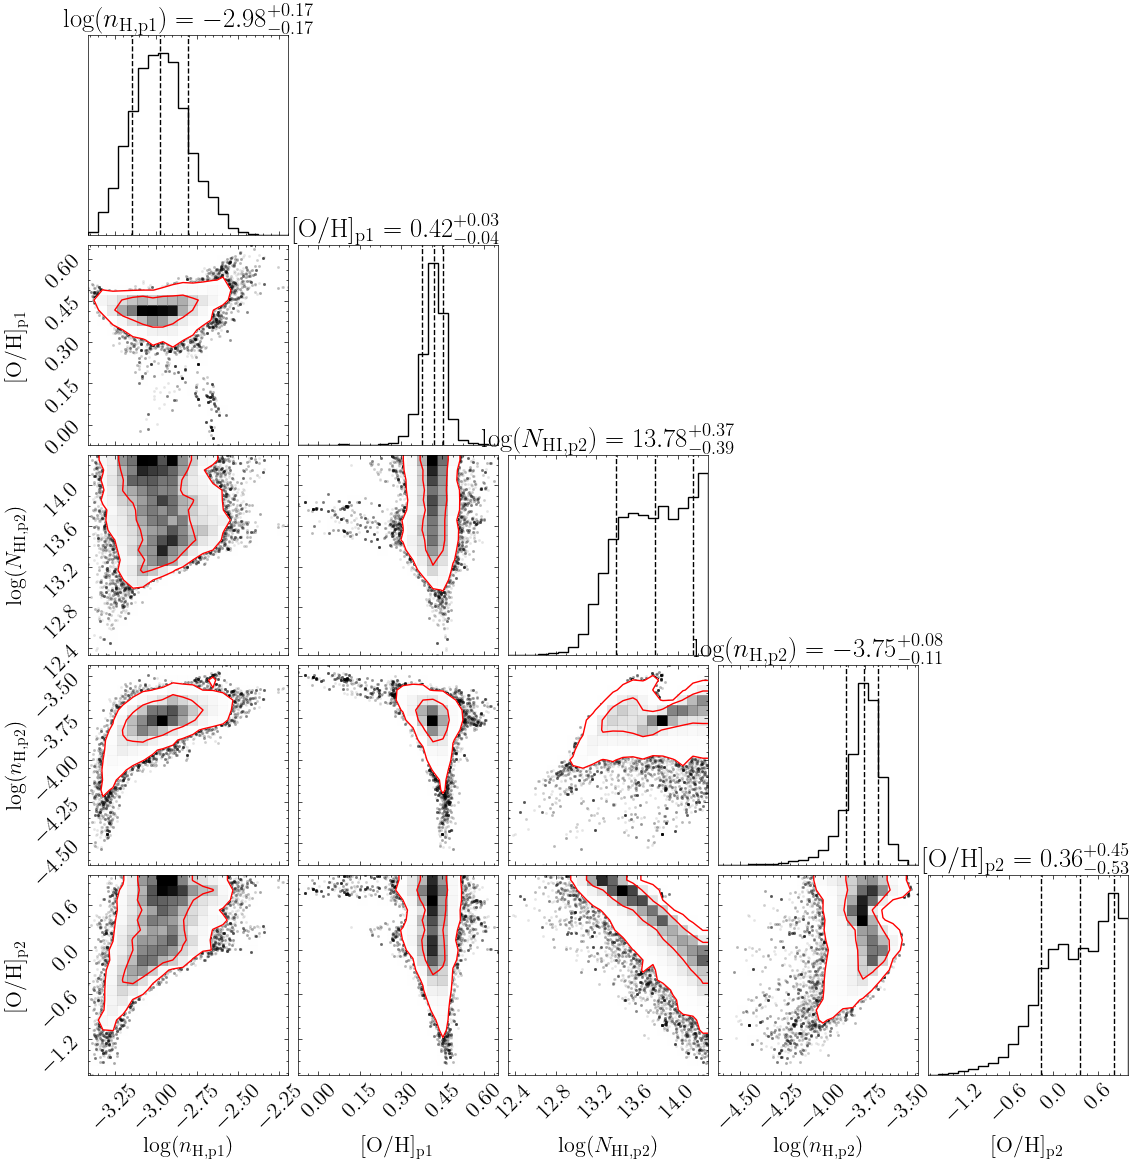

In [116]:
fig = corner.corner(
    flat_samples_two_phase, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$\log(n_\mathrm{H, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$',], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [117]:
logN_dict = {
        #'HI':'14.4, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'14.3, -0.2, +0.2',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.29, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.20, -0.05, +0.05',
        'OVI':'13.8, -0.2, +0.1',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',}
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',
        #'FeII':'<11.6'}

In [118]:
sample_indices_two_phase = np.random.randint(low=0, high=len(flat_samples_two_phase), size=500)

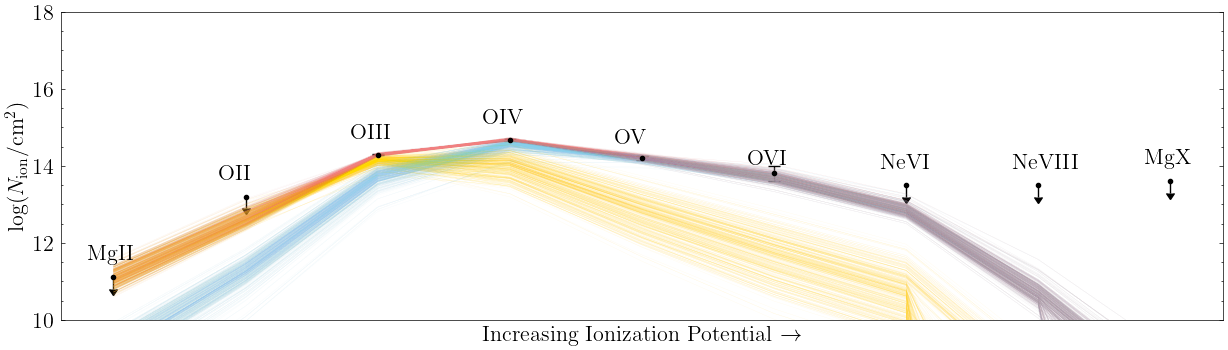

In [120]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_two_phase)):
    
    idx = sample_indices_two_phase[i]
    flat_samples_row = flat_samples_two_phase.iloc[i]
    
    log_hdens_p1 = flat_samples_row['log_hdens_p1']
    log_metals_p1 = flat_samples_row['log_metals_p1']
    
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    log_hdens_p2 = flat_samples_row['log_hdens_p2']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    
    logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_test,  log_hdens_p1, log_metals_p1, species_logN_interp))
    logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2,  log_hdens_p2, log_metals_p2, species_logN_interp))

    logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.1)
    ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='gold', lw=.2, alpha=.1)
    ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='skyblue', lw=.2, alpha=.1)

Get cloud sizes

In [121]:
l_p1 = np.zeros(len(flat_samples_two_phase))
l_p2 = np.zeros(len(flat_samples_two_phase))

In [122]:
for i in range(len(l_p1)):
    
    flat_samples_row = flat_samples_two_phase.iloc[i]
    
    l_p1[i] = get_cloud_size(logN_HI_test, flat_samples_row['log_hdens_p1'], species_logN_interp)
    l_p2[i] = get_cloud_size(flat_samples_row['logN_HI_p2'], flat_samples_row['log_hdens_p2'], species_logN_interp)

Text(0, 0.5, 'Counts')

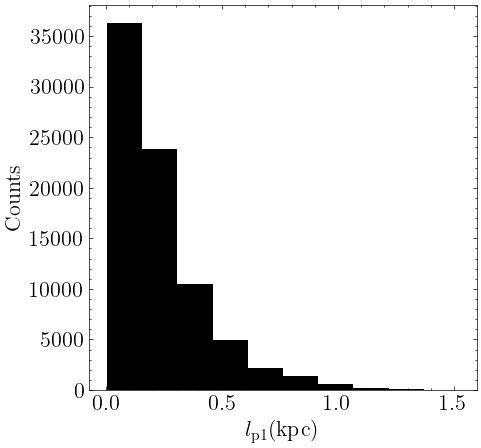

In [123]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_p1, bins=10)

ax.set_xlabel(r'$l_{\mathrm{p1}} (\mathrm{kpc})$')
ax.set_ylabel('Counts')

In [124]:
np.percentile(l_p1, 100*cdf_3sig)

1.1909947951548612

Text(0, 0.5, 'Counts')

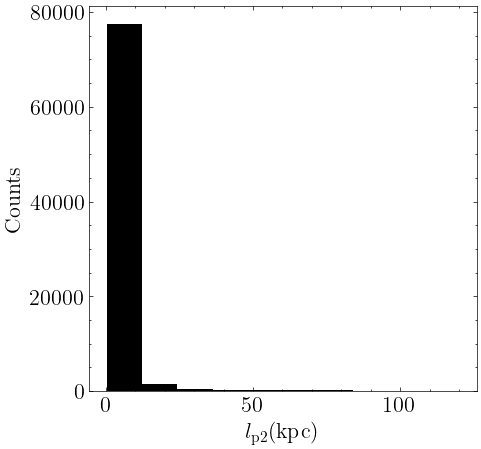

In [125]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_p2, bins=10)

ax.set_xlabel(r'$l_{\mathrm{p2}} (\mathrm{kpc})$')
ax.set_ylabel('Counts')

In [126]:
np.percentile(l_p2, 100*cdf_3sig)

83.04656684819749